In [15]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 4-1
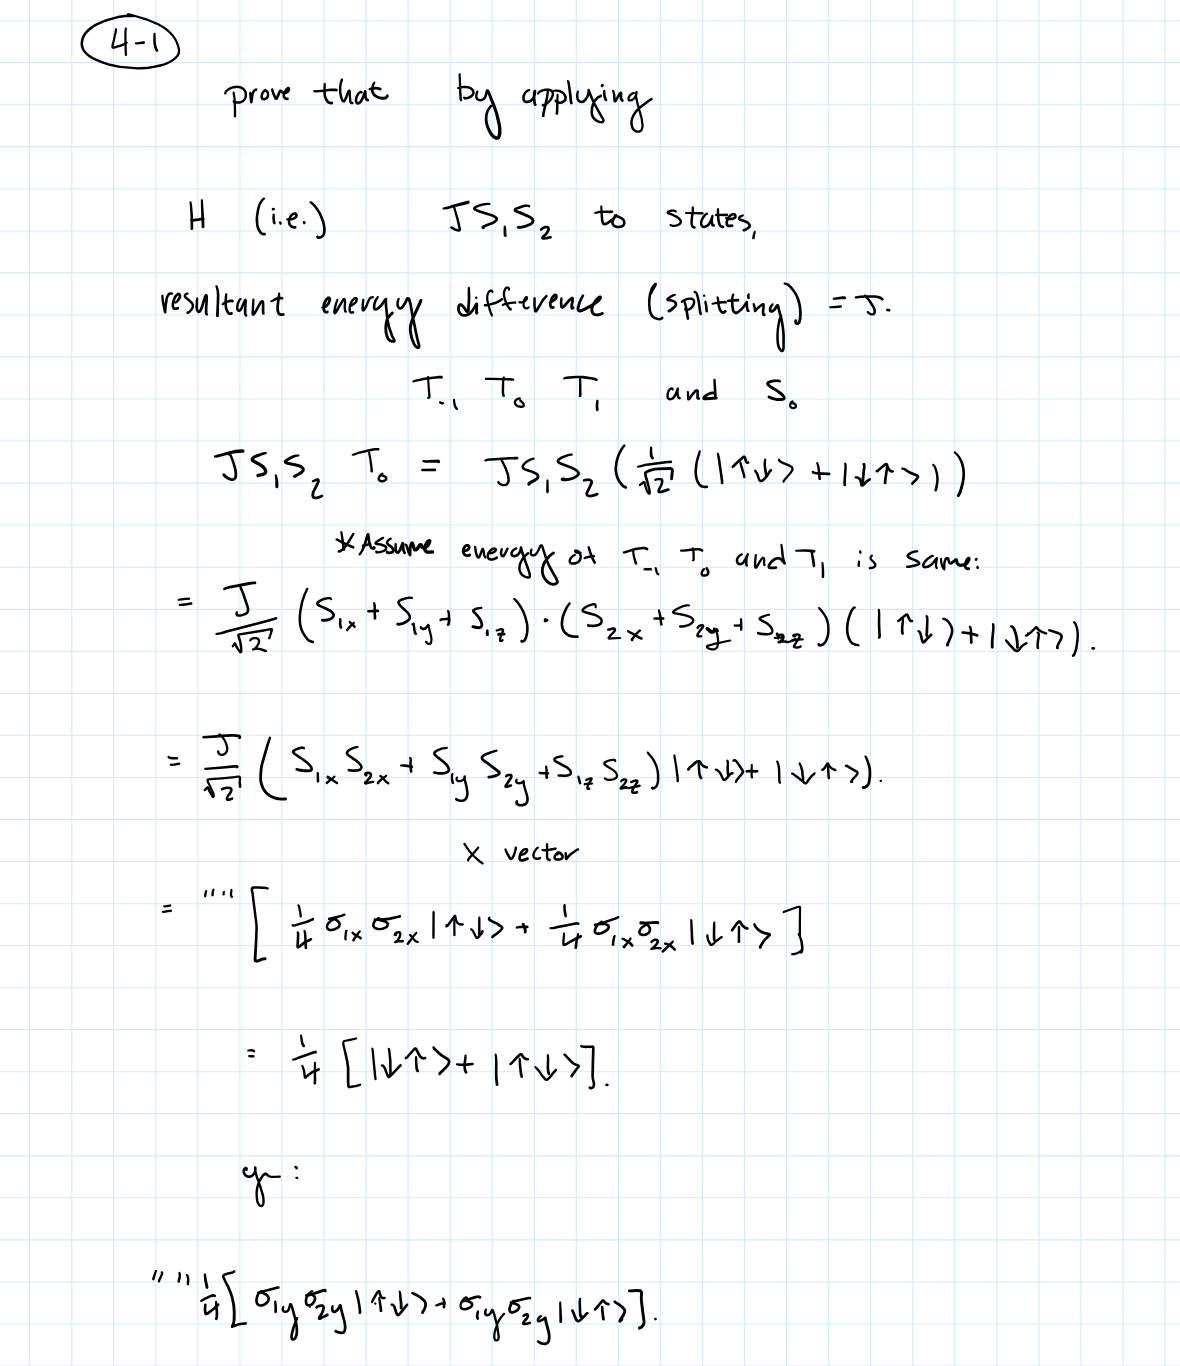
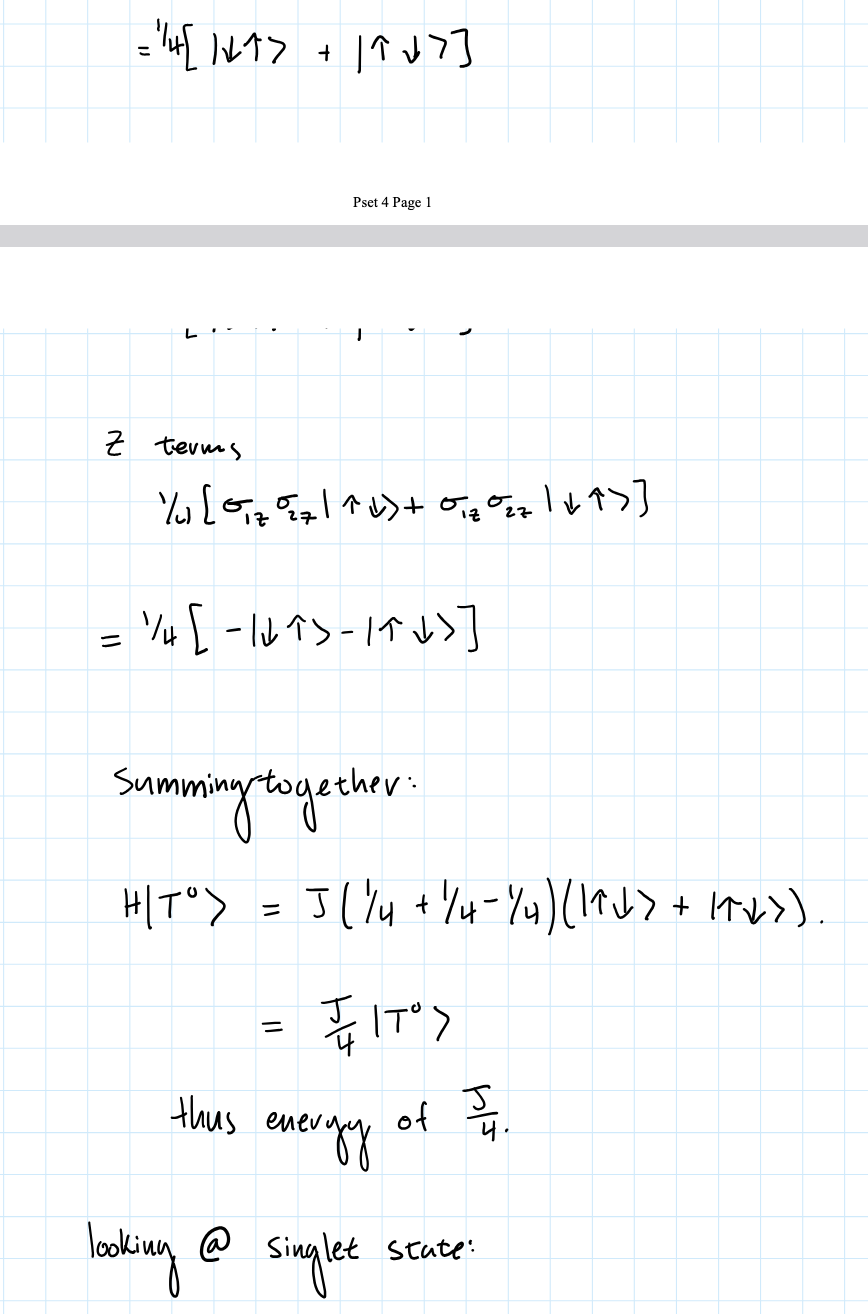
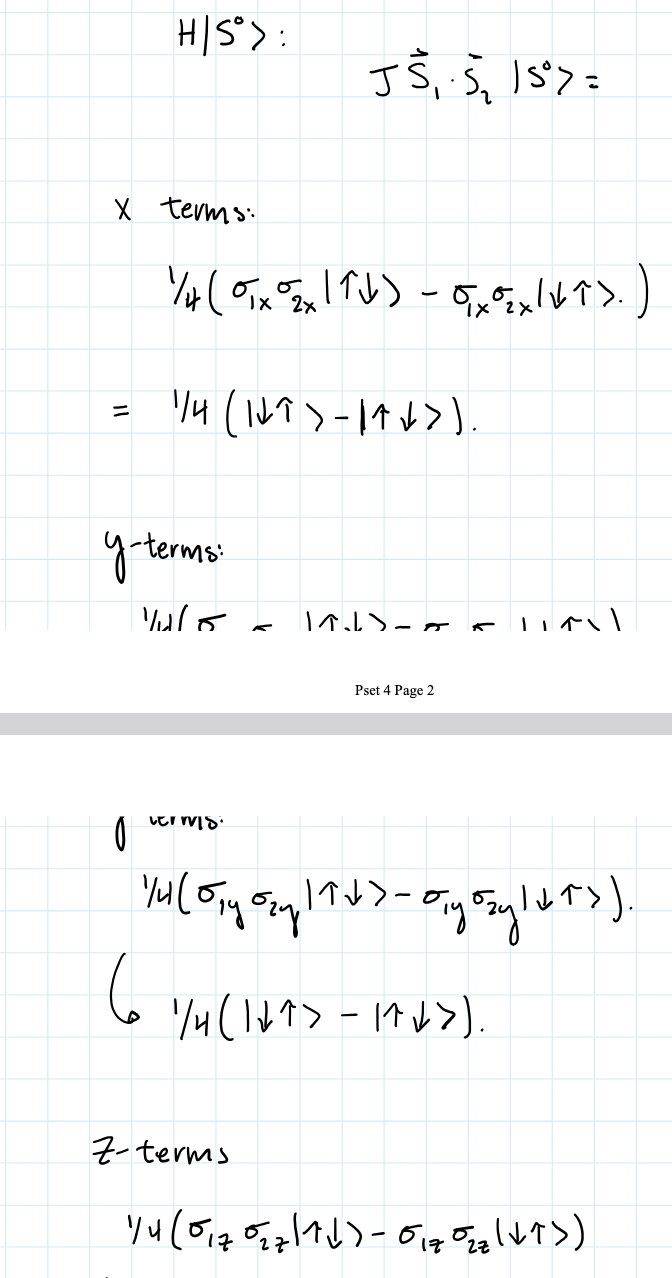
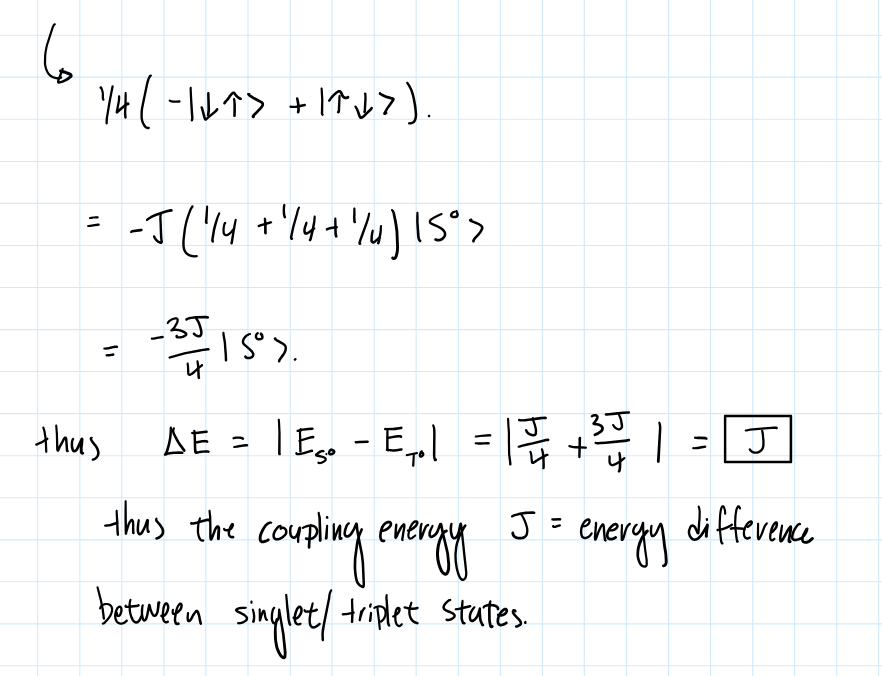

# 4-2

## (a)
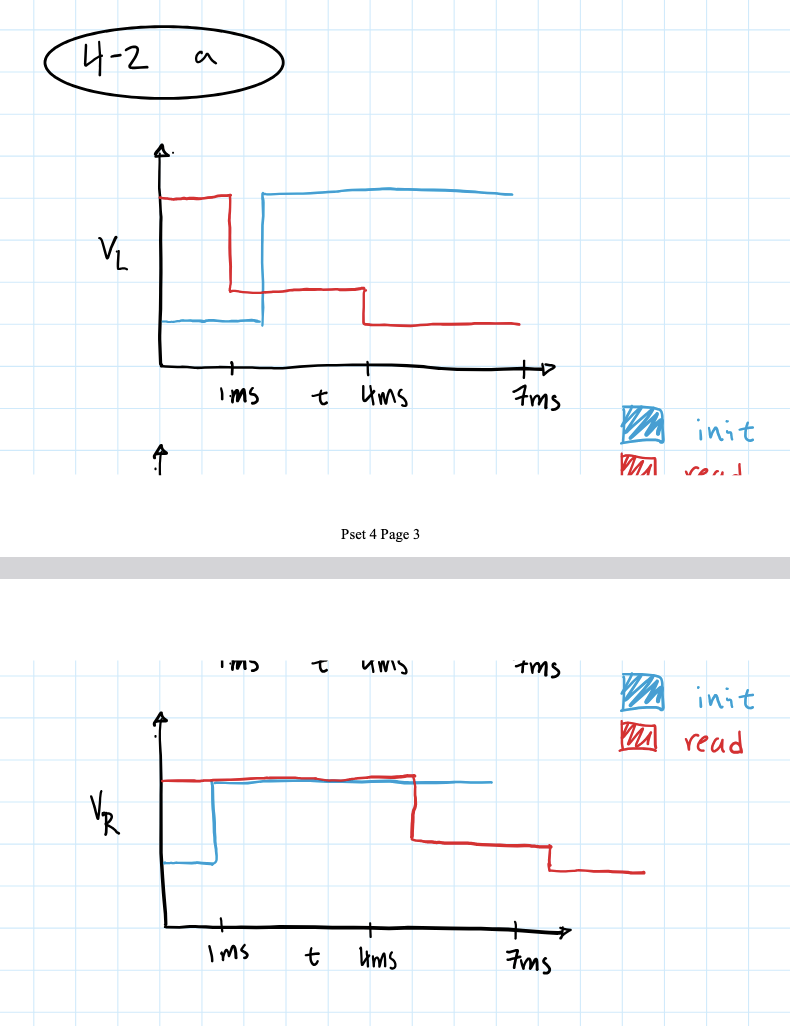

## (b)
### (i)
The authors specify that each qubit has a different Larmor frequency due to differences in the magnetic field applied from the Co magnet causing different levels of energy splitting between the up and down states. This is shown schematically by the differing gaps in energy as $E_{Z,R}$ and $E_{Z,L}$.

## (ii)
The electric field of S phyisically jostles the electrons in each q-dot in a sinusoidal manner along the z axis. Because the Co micromagnet creates a strong gradient along the z axis of the magnetic field of the y axis, this physical oscillation creates an effective sinusoidally changing magnetic field from the perspective of an electron in each q-dot. Thus, if we change the frequency of the microwave being used to drive S to match the Larmor frequency of the electron, we can drive the electrons as "normal."
Parameters affecting the Rabi frequency:
- The magnetic field gradient $\frac{dB_y}{dz}$: The greater this gradient, the more a small movement will increase the effective Rabi frequency of the dot
- The amplitude of the microwave pulse through S combined with the physical properties of the dot additionally impact how fast the dot will oscillate in the z-direction, which impacts the ratio of E to Rabi freqency.

## (c)
### (i)

In [16]:
import scipy.constants as const

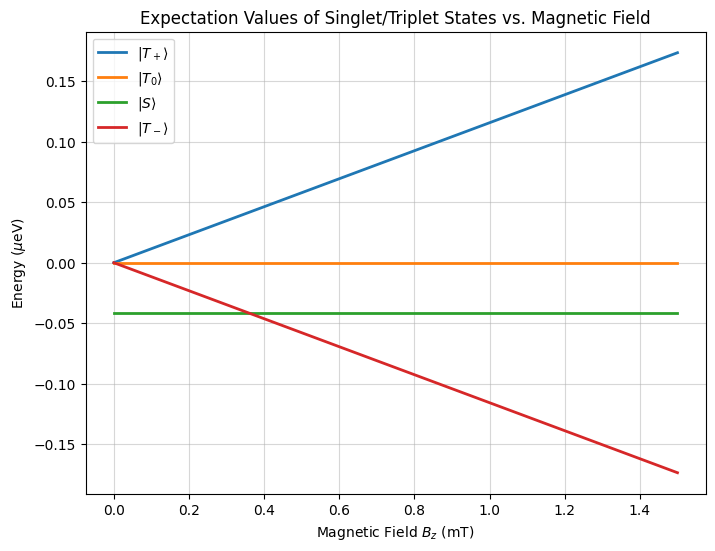

In [17]:
# constants
g = 2.0 # approx g constant in scilicon 
BOHR_eV = const.value('Bohr magneton in eV/T')
# convert to micro eV
BOHR = BOHR_eV * 1e6
h_eV = const.value('Planck constant in eV/Hz')
h = h_eV * 1e6 # micro eV again

# using the J value from the paper of 10MHz
J_freq = 10e6
J = h * J_freq # exchange energy in ueV

# Define our eigenstates
up = qt.basis(2, 0)
down = qt.basis(2, 1)

T_plus = qt.tensor(up, up)
T_minus = qt.tensor(down, down)
T_0 = 1/np.sqrt(2) * (qt.tensor(up, down) + qt.tensor(down, up))
S_0 = 1/np.sqrt(2) * (qt.tensor(up, down) - qt.tensor(down, up))

# ops
I = qt.qeye(2)
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
tensor = qt.tensor

S1x = tensor(X, I) / 2
S1y = qt.tensor(Y, I) / 2
S1z = qt.tensor(Z, I) / 2

S2x = qt.tensor(I, X) / 2
S2y = qt.tensor(I, Y) / 2
S2z = qt.tensor(I, Z) / 2

S1S2 = (S1x * S2x) + (S1y * S2y) + (S1z * S2z)

# Exchang hamiltonian defined from supplementary materials
H = J * (S1S2 - 0.25*tensor(I, I))

Bz_vals = np.linspace(0, 1.5e-3, 200)

E_Tplus = []
E_Tmin = []
E_Tnaught = []
E_S = []

for Bz in Bz_vals:
    # Calculate energy and add output energies:
    H_tot = g * BOHR * Bz * (S1z + S2z) + H
    E_Tplus.append(qt.expect(H_tot, T_plus))
    E_Tmin.append(qt.expect(H_tot, T_minus))
    E_Tnaught.append(qt.expect(H_tot, T_0))
    E_S.append(qt.expect(H_tot, S_0))

plt.figure(figsize=(8, 6))

# multiply Bz by 1000 to display in milliTesla (mT)
plt.plot(Bz_vals * 1000, E_Tplus, lw=2, label=r'$|T_+\rangle$')
plt.plot(Bz_vals * 1000, E_Tnaught, lw=2, label=r'$|T_0\rangle$')
plt.plot(Bz_vals * 1000, E_S, lw=2, label=r'$|S\rangle$')
plt.plot(Bz_vals * 1000, E_Tmin, lw=2, label=r'$|T_-\rangle$')

plt.xlabel('Magnetic Field $B_z$ (mT)')
plt.ylabel('Energy ($\mu$eV)')
plt.title('Expectation Values of Singlet/Triplet States vs. Magnetic Field')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### (ii)
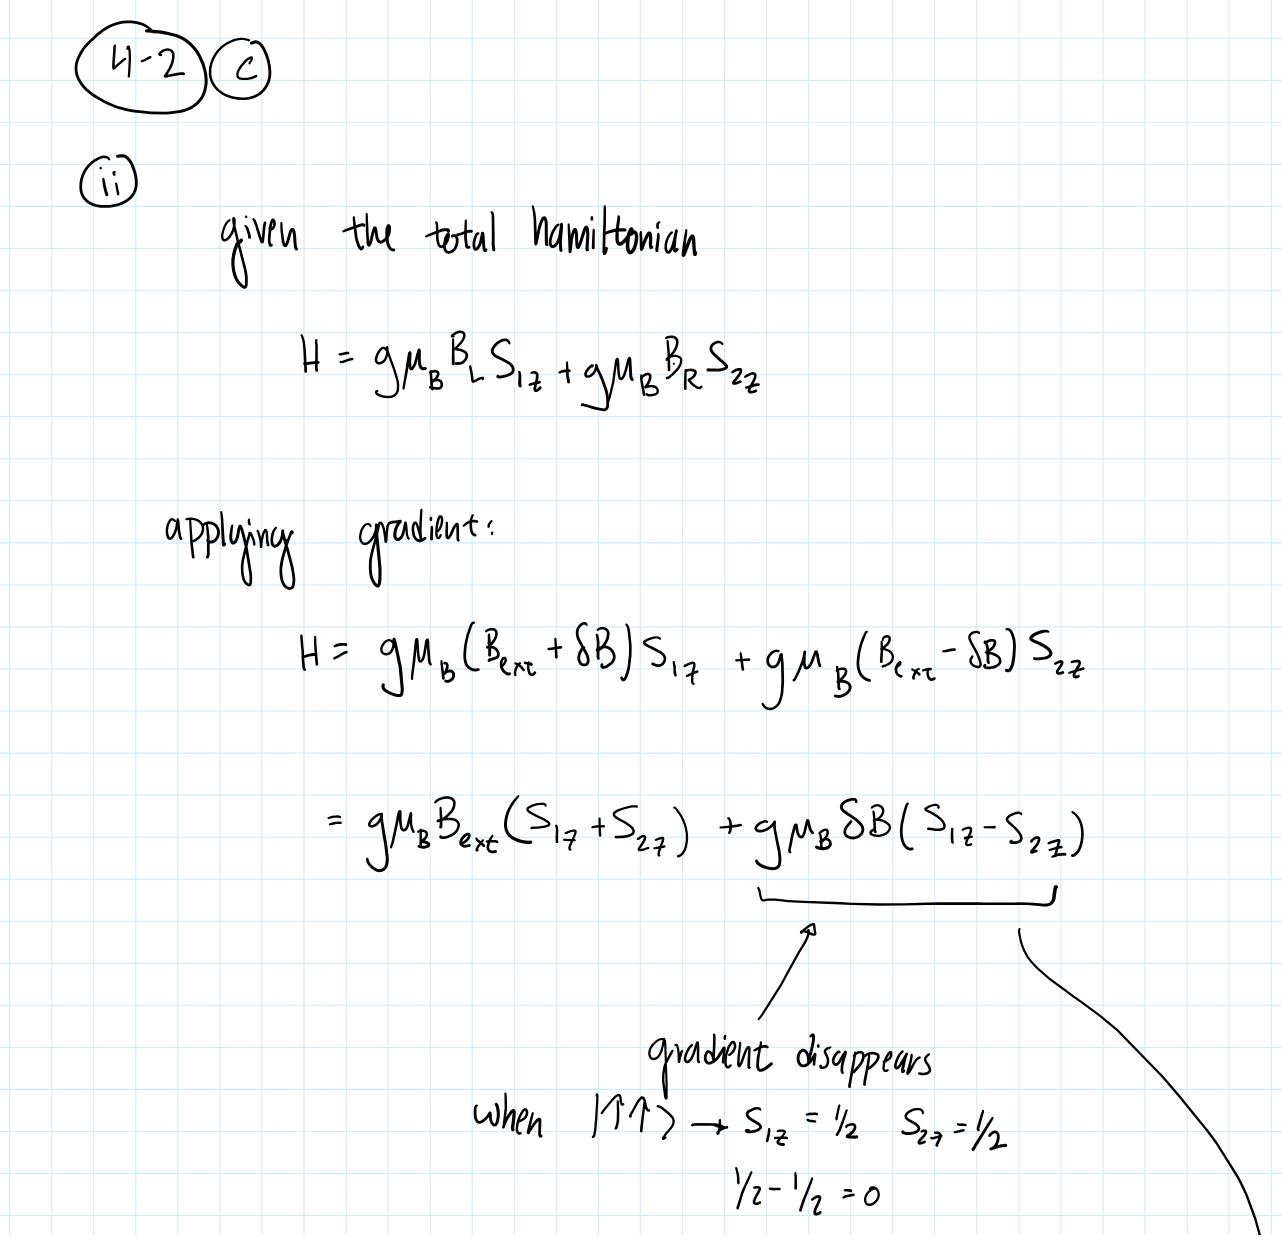
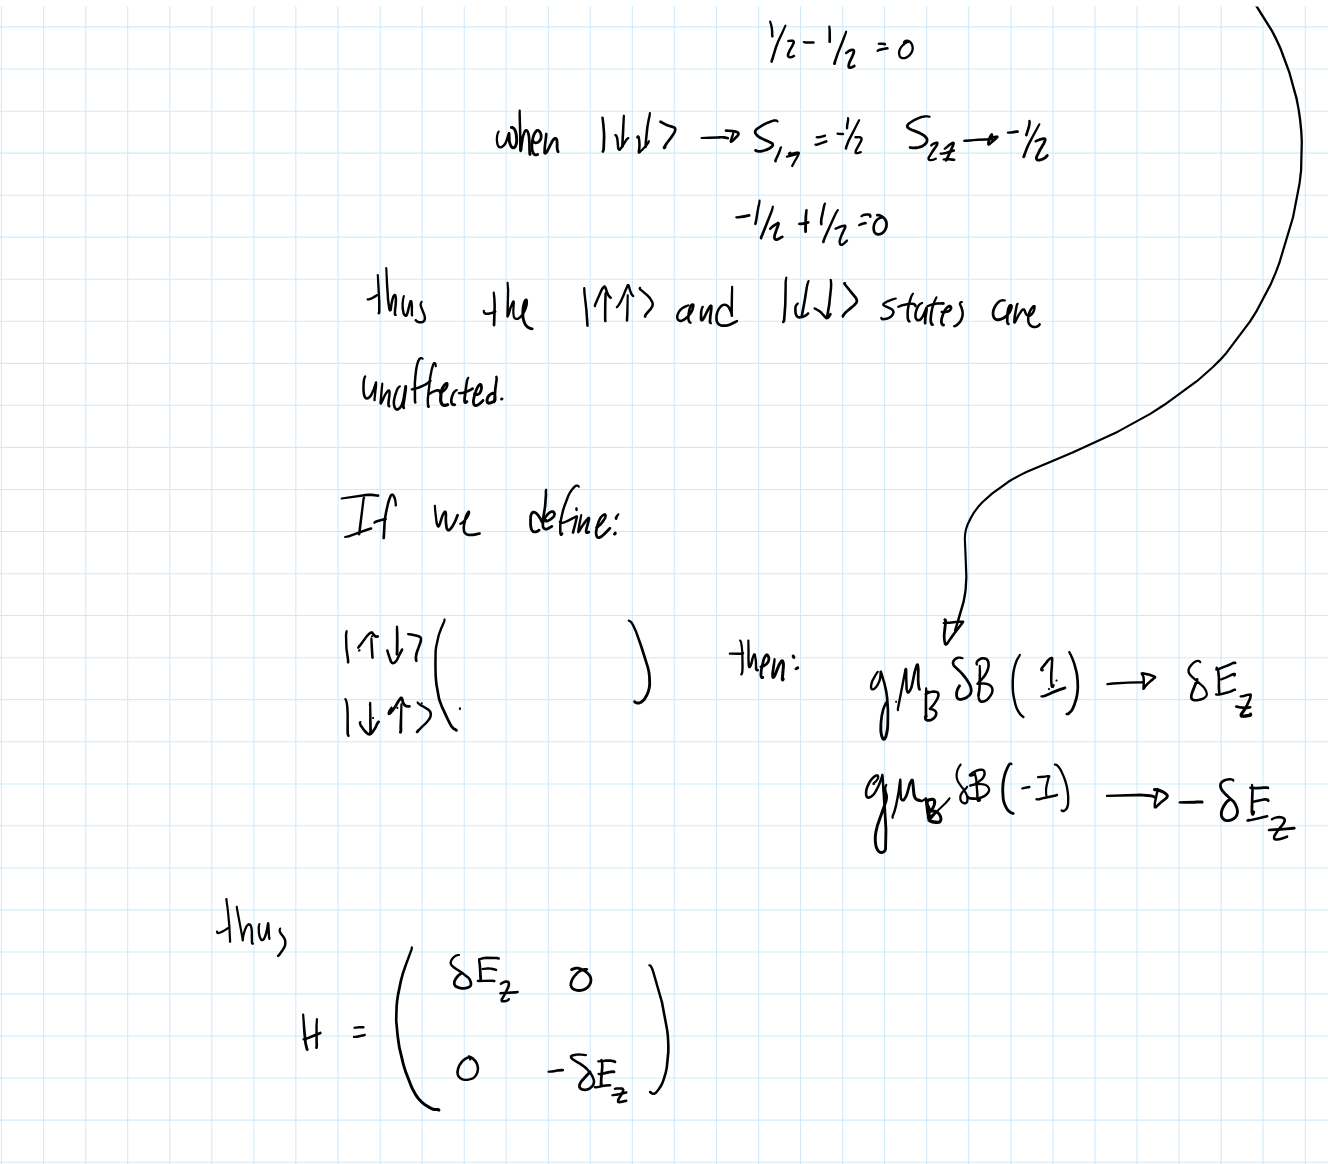
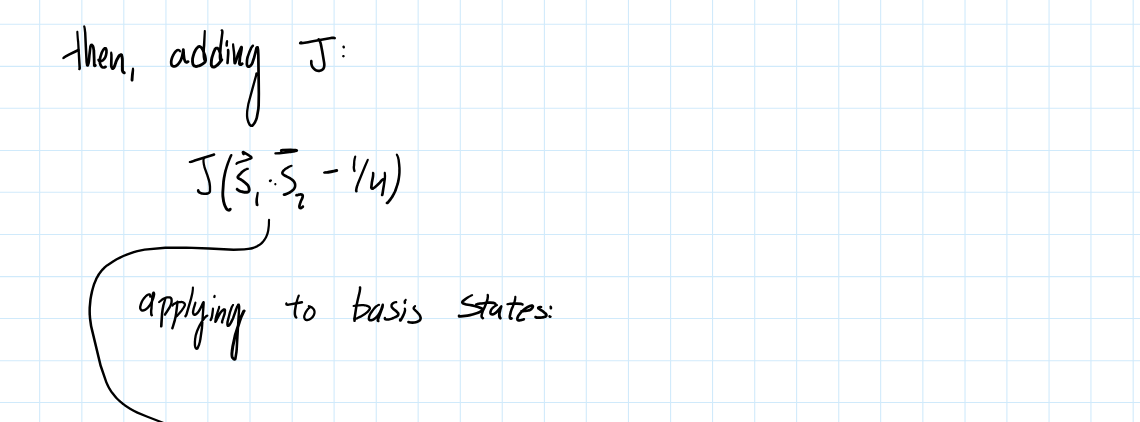
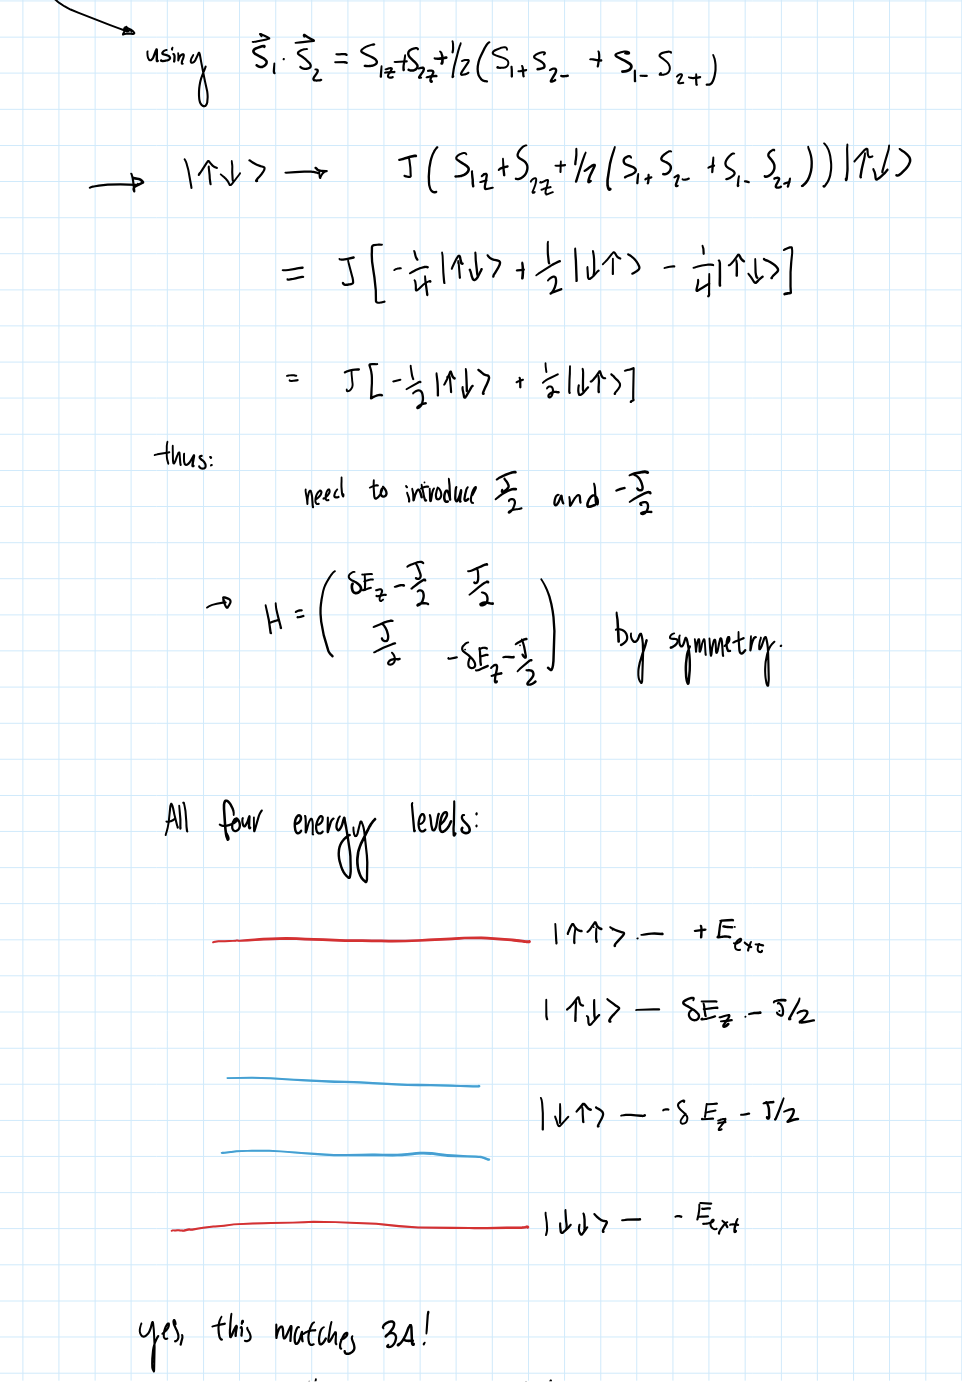
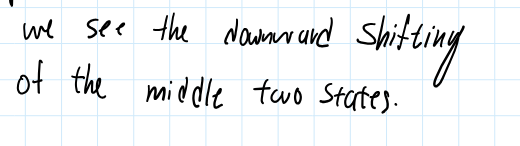

## (d)
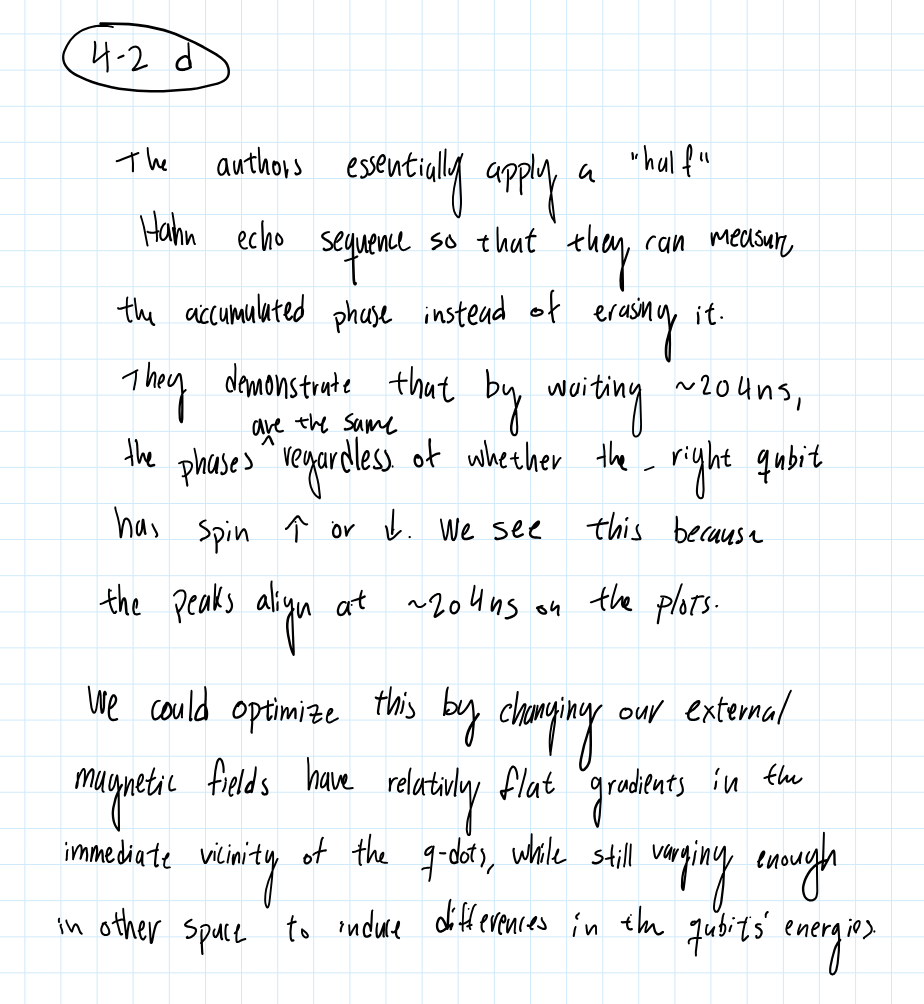


# 4-3

## (a)
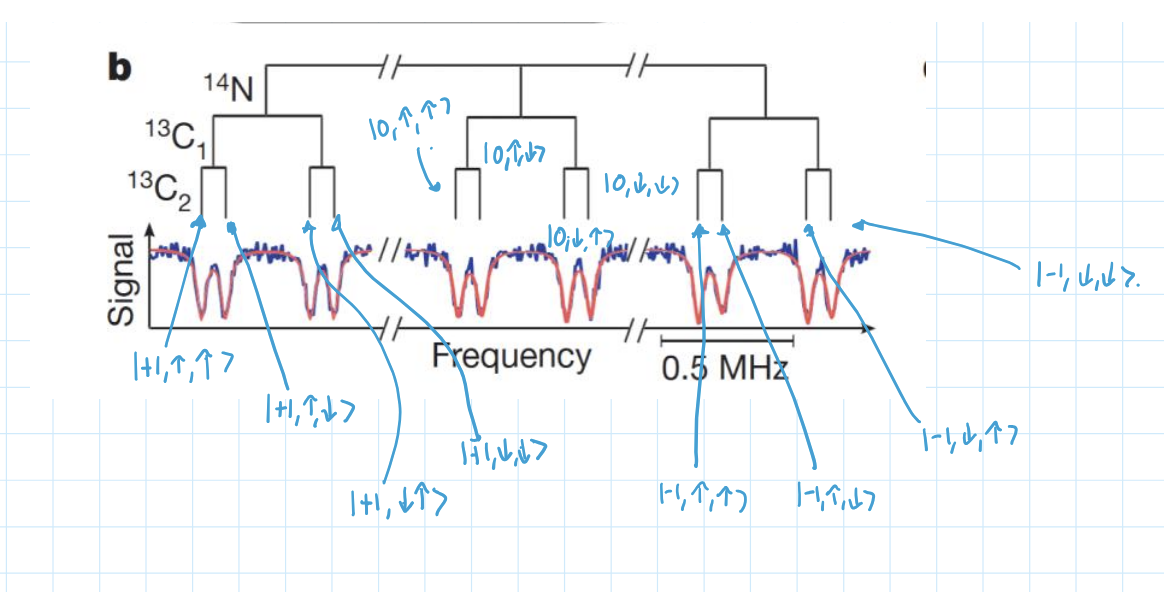

## (b)
The method outlined in the paper works by repeatedly measuring the electron in the NV center. While a single-shot measurement would still not output enough information to constitute a reliable measurement, the researchers instead initialize the nuclei neighboring the electron into the target quantum state, and then apply a CNOT gate on the electron, with regards to the surrounding nuclei. Then the electron is measured optically. This process can be repeated many times, however, because the nuclei are very well shielded and are more stable with regard to noise (also have very long lifetimes), the electron can be reinitialized and the process repeated until measurment is achieved with good fidelity.

## (c)
The authors call this a non-local gate because there is little direct physical (or local) interaction between the actual qubits of the system which are the spins of the nuclei. The NV center electron is used as the mediator of the interaction, because while the nuclei have an extremely weak interaction (any direct gates between them would be extremely slow), the electron has an extremely fast interaction due to the ratio of the gyromagnetic ratios for the e- vs the nuclei. The gate works by applying a pulse to the electron that will rotate it by $2\pi$, but only if the target nuclei is in an aligned spin. Because the electron is a spin 1/2 particle, a rotation by $2\pi$ will multiply the spin of the electron by -1, but only if the nuclei is in a certain spin state. By combining this gate with a series of gates on the $^{13}C_1$ qubit, this creates the standard CNOT gate.

## (d)
It seems the authors are able to get this extremely high fidelity not by achieving extremely good control over the quantum system, but instead by throwing out invalid states. They start by using a 70% or lower fidelity electron initialization, then transfer the electron's spin state to the nuclei. Then by applying a single-shot readout of the electron, they can see if they initialized the nuclei into the right state or not. Because this is a single shot measurement, there is inherent uncertainty as to whether the measurement is accurate, but by throwing out any state that the single shot measurement indidcates was not initialized correctly, by statistical selection extremely high fidelities (but importantly *not* high success rates) can be achieved.

In [ ]:
# x rotation
def rx(theta):
    return (-1j * (theta / 2.0) * qt.sigmax()).expm()

# |000>
# ordering: 14N, 13C1, 13C2
psi0 = tensor(
    qt.basis(2, 0),
    qt.basis(2, 0),
    qt.basis(2, 0)
    )

# essentially, 'select' the state we want to dephase
CPhase_111 = qt.Qobj(np.diag([1, 1, 1, 1, 1, 1, 1, -1]), dims=[[2, 2, 2], [2, 2, 2]])

CPhase_100 = qt.Qobj(np.diag([1, 1, 1, 1, -1, 1, 1, 1]), dims=[[2, 2, 2], [2, 2, 2]])

# Complete the transformations described in the paper
U1 = qt.tensor(rx(np.pi / 1.65), rx(np.pi / 2), rx(np.pi / 2))
psi_1 = U1 * psi0

psi_2 = CPhase_111 * psi_1

# second column
U3 = tensor(qt.qeye(2), rx(np.pi / 4), rx(np.pi / 2))
psi_3 = U3 * psi_2

# Two CPhases
psi_4 = CPhase_100 * psi_3
psi_5 = CPhase_111 * psi_4

# Final local rotation
U6 = tensor(qt.qeye(2), rx(np.pi / 4), qt.qeye(2))
psi_final = U6 * psi_5

# compare with W state
basis = qt.basis

psi_W = (tensor(basis(2, 0), basis(2, 1), basis(2, 1)) +
         tensor(basis(2, 1), basis(2, 0), basis(2, 1)) +
         tensor(basis(2, 1), basis(2, 1), basis(2, 0))).unit()

# verifying...
print("Fidelity with ideal W state:", qt.fidelity(psi_final, psi_W))

Fidelity with ideal W state: 0.9999944926412805


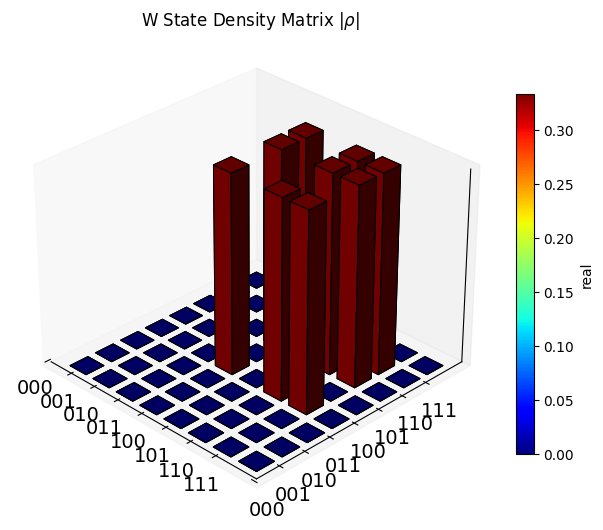

In [ ]:
ket0 = basis(2, 0)
ket1 = basis(2, 1)

rho_W = psi_W * psi_W.dag()

# apply abs as done in the paper
rho_abs = qt.Qobj(np.abs(rho_W.full()), dims=rho_W.dims) # must keep dims or else will be re-interpreted as 8x8 matrix instead of tensor

fig, ax = qt.matrix_histogram(rho_abs)

# graph and labels
labels = ['000', '001', '010', '011', '100', '101', '110', '111']
ticks = np.arange(len(labels))

ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax.set_title(r'W State Density Matrix |$\rho$|')

# Adjust the viewing angle to make it look like the paper
ax.view_init(elev=30, azim=-45)

plt.show()
